# 线性回归

## 一、线性回归从零实现

### 1.导入库

In [100]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

### 2.生成数据集

线性模型参数 $\mathbf{w} = [2, -3.4]^\top$、 $b = 4.2$
和噪声项 $\epsilon$ 生成数据集及其标签： $\mathbf{y}= \mathbf{X} \mathbf{w} + b + \mathbf\epsilon.$

In [101]:
# synthetic 的意思是合成的、模拟的
def synthetic_data(w, b, num_examples):  
    # 生成 y = Xw + b + 噪声
    # num_examples 是样本数量
    # torch.normal(均值, 标准差, shape)，生成服从正态分布的随机数
    X = torch.normal(0, 1, (num_examples, len(w)))
    # torch.matmul 矩阵乘法
    y = torch.matmul(X, w) + b
    # 生成噪声
    y += torch.normal(0, 0.01, y.shape)
    # -1表示这一维度自动计算，1是为了补全维度
    return X, y.reshape((-1, 1))
# 真实的 w 和 b
# w 是权重，2代表有两个权重，也就是两个特征
# b 是偏置
true_w = torch.tensor([2, -3.4])
true_b = 4.2
# 生成1000条数据，也就是 features 接收 X，labels 接收 y
# features 模型的输入即特征，labels 模型要学习预测的真实结果即标签
features, labels = synthetic_data(true_w, true_b, 1000)
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([-0.4066, -0.6935]) 
label: tensor([5.7415])


### 3.生成散点图

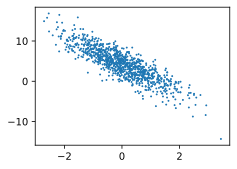

In [102]:
# 设置图片大小
d2l.set_figsize()
# 画散点图，第二个特征和 y 的关系
# plt.scatter(横坐标，纵坐标，散点大小)
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

### 4.读取数据集

In [103]:
# 把1000个样本打乱，然后每次随机取10个样本出来训练（小批量训练）
# batch_size = 10，每次取10个样本
def data_iter(batch_size, features, labels):
    # 函数结束，参数就销毁了，所以重新定义
    num_examples = len(features)
    # list(range(num_examples)) 得到 [0,1,2,3,...,999] 即样本编号
    indices = list(range(num_examples))
    # shuffle 洗牌
    # 希望每个 epoch 都随机读取数据，不受排列顺序影响
    random.shuffle(indices)
    # 0到 num_examples-1，每次加 batch_size，即0,10,...,990
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            # min 保证不会越界，不够10个，能取多少取多少
            indices[i: min(i + batch_size, num_examples)])
        # 取 batch_indices 行的数据，从第0行开始数
        # return 是返回一次，函数结束
        # yield 是返回一次，暂停，下一次继续
        yield features[batch_indices], labels[batch_indices]
batch_size = 10
# data_iter是上面的函数
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.2175, -0.0510],
        [ 0.1505,  0.6899],
        [-0.6860,  0.0937],
        [ 0.5557, -0.0274],
        [ 0.1537,  0.7939],
        [-0.0378,  0.2957],
        [ 1.4909, -0.2142],
        [-3.0526, -1.1854],
        [ 0.3579,  0.3225],
        [-0.1739, -0.8975]]) 
 tensor([[4.8121],
        [2.1571],
        [2.5078],
        [5.3947],
        [1.8001],
        [3.1117],
        [7.8972],
        [2.1392],
        [3.8177],
        [6.8955]])


### 5.初始化模型参数

In [104]:
# 后面就是要训练 w 和 b
# requires_grad=True 需要计算梯度
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

### 6.定义模型

In [105]:
# 定义函数名字是 linreg
# y = Xw + b 看出是线性回归模型
def linreg(X, w, b):  
    return torch.matmul(X, w) + b

### 7.定义损失函数

In [106]:
# y_hat 是模型预测值，y 是真实值
# squared_loss 平方损失
def squared_loss(y_hat, y):  
    # reshap 保证维度一样
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

### 8.定义优化算法

In [107]:
# sgd 小批量随机梯度下降
# params 就是 [w, b]
# lr 是学习率，决定一步走多远，梯度决定方向
def sgd(params, lr, batch_size):  
    # 下面更新参数时，不要记录梯度，不然浪费内存
    with torch.no_grad():
        # 第一次循环 param 等于 w，第二次等于 b
        for param in params:
            # 梯度下降公式
            # / batch_size 得到平均梯度
            param -= lr * param.grad / batch_size
            # 梯度清零，默认梯度累加
            param.grad.zero_()

### 8.训练

In [108]:
lr = 0.03
# epoch 轮次
num_epochs = 3
# 模型函数保存到变量 net
net = linreg
loss = squared_loss
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量，l中的所有元素被加到一起
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        # 使用参数的梯度更新参数
        sgd([w, b], lr, batch_size)  
    # 测试模型效果，不需要梯度
    with torch.no_grad():
        # 用全部1000个数据测试当前模型
        train_l = loss(net(features, w, b), labels)
        # epoch 是0，1，2，加1方便阅读
        # f'...'，输出...
        # float() 把其他类型转换成浮点数
        # :f 格式化字符串的格式说明符，:2f，两位小数
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.039036
epoch 2, loss 0.000148
epoch 3, loss 0.000053


### 9.比较真实和训练参数

In [109]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([ 7.9870e-06, -2.6250e-04], grad_fn=<SubBackward0>)
b的估计误差: tensor([-0.0002], grad_fn=<RsubBackward1>)


## 二、线性回归简洁实现

### 1.生成数据集

In [110]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

### 2.读取数据集

In [111]:
# 把数据包装成 PyTorch 可以按 batch 读取的数据迭代器
# data_arrays 传入 (features, labels)
# is_train 训练模式会打乱数据，测试模式保持原顺序
def load_array(data_arrays, batch_size, is_train=True):  
    # Dataset 是把数据打包成一个数据集对象
    # TensorDataset 将特征和标签一一对应绑定
    # * 是拆包
    dataset = data.TensorDataset(*data_arrays)
    # DataLoader 从 Dataset 中按照 batch 取数据
    return data.DataLoader(dataset, batch_size, shuffle=is_train)
batch_size = 10
data_iter = load_array((features, labels), batch_size)
# next(...) 取第一个元素
next(iter(data_iter))

[tensor([[-2.0489, -1.2322],
         [-1.0883,  0.9538],
         [-1.5537, -1.3307],
         [-0.3514, -1.0217],
         [-0.2741,  0.0792],
         [-0.5430, -0.8758],
         [ 1.3003, -0.3128],
         [ 0.8728,  0.3592],
         [-0.1114,  0.1278],
         [-0.5471,  1.8892]]),
 tensor([[ 4.2735],
         [-1.1967],
         [ 5.6087],
         [ 6.9763],
         [ 3.3778],
         [ 6.0982],
         [ 7.8518],
         [ 4.7199],
         [ 3.5223],
         [-3.3093]])]

### 3.定义模型

In [112]:
# nn 是 neural network（神经网络）的缩写
# 导入神经网络模块
from torch import nn
# nn.Linear(2, 1) 创建一个线性层
# 2代表输入特征有两个，1代表输出一个值
# nn.Sequential() 按顺序组合网络层
net = nn.Sequential(nn.Linear(2, 1))

### 4.初始化模型参数

In [113]:
# 神经网络此时只有一个层，net(0) 表示第0层
net[0].weight.data.normal_(0, 0.01)
# fill_(0) 填充0
net[0].bias.data.fill_(0)

tensor([0.])

### 5.定义损失函数

In [114]:
# 创建一个均方误差损失函数
loss = nn.MSELoss()

### 6.定义优化算法

In [115]:
# 创建一个随机梯度下降优化器，用来自动更新神经网络的参数
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

### 7.训练

In [116]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X) ,y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')


epoch 1, loss 0.000256
epoch 2, loss 0.000097
epoch 3, loss 0.000098


### 8.比较真实和训练参数

In [117]:
w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：', true_b - b)

w的估计误差： tensor([-4.1723e-05, -1.0395e-04])
b的估计误差： tensor([0.0006])
